In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

_root = Path.cwd()
while not (_root / "analyst").exists() and _root != _root.parent:
    _root = _root.parent

sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / "src"))

from analyst.lib.table_formatting import display_analysis_table, format_analysis_table
import analyst.lib.plot_utils as pu

LAB_DB = str(_root / "database" / "solusdt" / "solusdt_lab.duckdb")
MODEL_ID = "lgbm_solusdt_l_fw60_2101_2605"
SAMPLE_TABLE = f'model."{MODEL_ID}__sample"'

CQ_COLORS = {
    "blue":       "#1696d2",
    "black":      "#000000",
    "gray_dark":  "#353535",
    "gray":       "#696969",
    "gray_light": "#d2d2d2",
    "yellow":     "#fdbf11",
    "orange":     "#f15a24",
    "red":        "#ec008b",
}
CQ_SEQUENCE = [
    CQ_COLORS["blue"],
    CQ_COLORS["yellow"],
    CQ_COLORS["orange"],
    CQ_COLORS["gray"],
    CQ_COLORS["red"],
]

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (9, 5.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": CQ_COLORS["gray"],
        "axes.labelcolor": CQ_COLORS["gray_dark"],
        "xtick.color": CQ_COLORS["gray_dark"],
        "ytick.color": CQ_COLORS["gray_dark"],
        "grid.color": CQ_COLORS["gray_light"],
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "legend.frameon": False,
    },
)
sns.set_palette(CQ_SEQUENCE)

## Cél

Ez a notebook a `model."lgbm_solusdt_l_fw60_2101_2605__sample"` tábla szerkezetét és
tartalmát vizsgálja SOLUSDT 1m granularitásban.
Vizsgált területek: teljes minta lefedettség (min/max dátum, darabszám),
fold-szintű bontás (határok, méret, átlagos target), és a target időbeli alakulása.

**Kapcsolódó dokumentáció:**
- Módszertan: `_doc_/methodology_doc/5400_sampling.md`
- Módszertan: `_doc_/methodology_doc/5010_sampling_yearly.md`

**Asset:** SOLUSDT | **Granularitás:** 1m | **Dátum:** 2026-06-23

**Walk-forward konfiguráció:** 9m train + 8m valid, 8m shift, 4 fold, anchor: 2023-01

## Teljes minta összesítő

**Mi ez.** A sampling tábla teljes kiterjedése: legkorábbi és legkésőbbi időbélyeg,
valamint a sorok teljes száma.

**Forrás.** `model."lgbm_solusdt_l_fw60_2101_2605__sample"` tábla, `open_time` oszlop.

**Módszer.** MIN / MAX / COUNT(*) aggregáció az egész táblán, fold-szűrés nélkül.

**Értelmezés.** A tartomány várhatóan 2021-01 – 2026-05 közé esik (a champion modell
teljes walk-forward ablakja). Az órránkénti determinisztikus pick miatt a sorok száma
kb. ~47 000 körül várható (≈ 65 hónap × 720 óra × ~1 sor/óra).

In [2]:
#| label: tbl-overall-summary
#| tbl-cap: "Teljes sampling tábla összesítő — min/max dátum és sorszám"

con = duckdb.connect(LAB_DB, read_only=True)
overall = con.execute(f"""
    SELECT
        MIN(open_time)  AS min_date,
        MAX(open_time)  AS max_date,
        COUNT(*)        AS count
    FROM {SAMPLE_TABLE}
""").fetchdf()
con.close()

overall["min_date"] = pd.to_datetime(overall["min_date"]).dt.strftime("%Y-%m-%d %H:%M")
overall["max_date"] = pd.to_datetime(overall["max_date"]).dt.strftime("%Y-%m-%d %H:%M")

display_analysis_table(overall)

min_date,max_date,count
2021-01-01 00:58,2026-05-31 23:50,47448


## Fold összesítő — tényleges train/valid split

**Mi ez.** Walk-forward CV-ben minden foldnak van egy **valid** ablaka és egy **train** halmaza.
A `train_months` paraméter csak a fold_time_windows metaadatában szerepel mint referencia
ablak — a tényleges search kód `train_mask = ~valid_mask & ~purge_mask` logikát alkalmaz,
azaz minden sor train, ami nem a fold valid ablakában és nem a purge zónában van.

Ez azt jelenti: a 2021–2022 sorok benne vannak az összes fold train halmazában.
Ráadásul fold 1 train-je tartalmazza fold 2/3/4 valid adatait is (jövőbeli sorok).
Ez a CV nem klasszikus expanding-window walk-forward — inkább "minden sor train,
kivéve a validált ablak".

**Forrás.** `model."lgbm_solusdt_l_fw60_2101_2605__sample"` + search kód split logikája
(`src/modeling/search/lgbm_search.py`, `_fold_split_walk_forward`).

**Módszer.** Fold_time_windows alapján valid_mask és purge_mask épül; train_mask = NOT valid AND NOT purge.
Purge: 240 perces buffer a valid határok körül.

**Értelmezés.** A CV estimate-ek optimisták lehetnek, ha a korai foldok train-je
jövőbeli data-t lát — ezt szem előtt kell tartani az OOS értékelésnél.

In [3]:
#| label: tbl-fold-train-valid
#| tbl-cap: "Fold tényleges train/valid split — a search kód ~valid_mask & ~purge_mask logikájával"

from modeling.sampling.yearly_sampler import generate_walk_forward_folds

fold_windows = generate_walk_forward_folds(
    year=2023, train_months=9, valid_months=8,
    shift_months=8, purge_minutes=240, n_folds=4,
)

con = duckdb.connect(LAB_DB, read_only=True)
df_full = con.execute(f"SELECT open_time, long_mfe_fw60, fold_id FROM {SAMPLE_TABLE} ORDER BY open_time").fetchdf()
con.close()

df_full["open_time"] = pd.to_datetime(df_full["open_time"])
PURGE = pd.Timedelta(minutes=240)

rows = []
for fw in fold_windows:
    fid = fw["fold_id"]
    valid_start = pd.Timestamp(fw["valid_start"])
    valid_end   = pd.Timestamp(fw["valid_end"])   + pd.Timedelta(hours=23, minutes=59)
    train_end   = pd.Timestamp(fw["train_end"])   + pd.Timedelta(hours=23, minutes=59)

    valid_mask = (df_full["open_time"] >= valid_start) & (df_full["open_time"] <= valid_end)
    purge_mask = (
        (df_full["open_time"] > train_end) & (df_full["open_time"] < valid_start)
    ) | (
        (df_full["open_time"] > valid_end) & (df_full["open_time"] <= valid_end + PURGE)
    )
    train_mask = ~valid_mask & ~purge_mask

    tr = df_full[train_mask]
    va = df_full[valid_mask]

    rows += [
        {"fold": fid, "part": "train",
         "min_date": str(tr["open_time"].min().date()),
         "max_date": str(tr["open_time"].max().date()),
         "count": len(tr), "avg_target": tr["long_mfe_fw60"].mean()},
        {"fold": fid, "part": "valid",
         "min_date": str(va["open_time"].min().date()),
         "max_date": str(va["open_time"].max().date()),
         "count": len(va), "avg_target": va["long_mfe_fw60"].mean()},
    ]

display_analysis_table(pd.DataFrame(rows))

fold,part,min_date,max_date,count,avg_target
1,train,2021-01-01,2026-05-31,41588,0.007
1,valid,2023-10-01,2024-05-31,5856,0.007
2,train,2021-01-01,2026-05-31,41564,0.007
2,valid,2024-06-01,2025-01-31,5880,0.006
3,train,2021-01-01,2026-05-31,41636,0.007
3,valid,2025-02-01,2025-09-30,5808,0.005
4,train,2021-01-01,2025-09-30,41616,0.008
4,valid,2025-10-01,2026-05-31,5832,0.004


## Target alakulása — train vs valid foldonként

**Mi ez.** Az átlagos `long_mfe_fw60` foldonként, train és valid részenkénti bontásban.
A train/valid gap és a valid trend egyszerre látható.

**Forrás.** Az előző szekció fold_df táblája.

**Értelmezés.** Ha a valid rendre alacsonyabb mint a train ugyanazon a foldon, az azt
jelenti, hogy a modell egy magasabb target-szintű perióduson tanul, mint amin validálandó.
A trend iránya (csökken-e foldonként a valid?) megmutatja, hogy a piac strukturálisan
változik-e a CV horizonton.

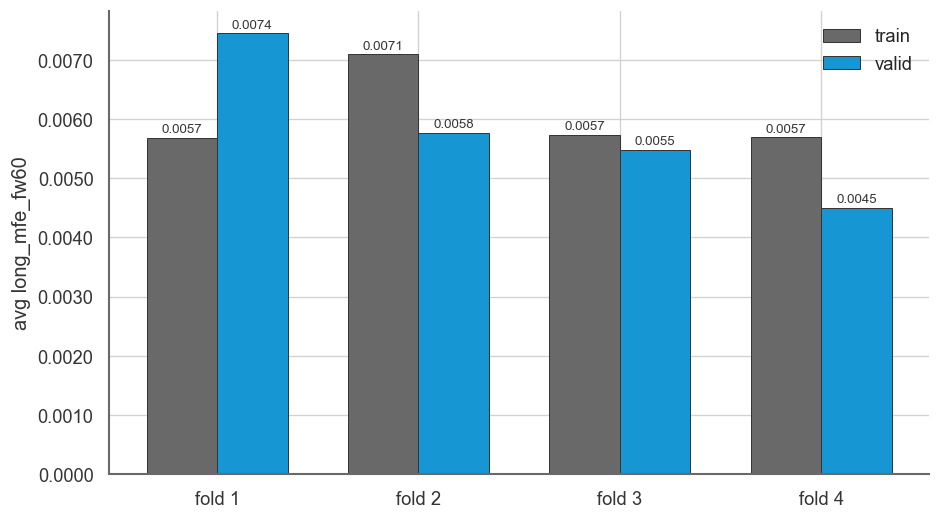

In [4]:
#| label: fig-train-valid-avg-target
#| fig-cap: "Átlagos long_mfe_fw60 — train (szürke) vs. valid (kék) foldonként"
#| fig-alt: "Csoportosított sávdiagram: train és valid avg_target összehasonlítása foldonként."

from modeling.sampling.yearly_sampler import generate_walk_forward_folds
import numpy as np

fold_windows = generate_walk_forward_folds(
    year=2023, train_months=9, valid_months=8,
    shift_months=8, purge_minutes=240, n_folds=4,
)

con = duckdb.connect(LAB_DB, read_only=True)
_plot_rows = []
for fw in fold_windows:
    fid = fw["fold_id"]
    tr = con.execute(f"""
        SELECT AVG(long_mfe_fw60) FROM {SAMPLE_TABLE}
        WHERE open_time >= '{fw["train_start"]}' AND open_time <= '{fw["train_end"]} 23:59:59'
    """).fetchone()[0]
    va = con.execute(f"""
        SELECT AVG(long_mfe_fw60) FROM {SAMPLE_TABLE} WHERE fold_id = {fid}
    """).fetchone()[0]
    _plot_rows.append({"fold": fid, "train": tr, "valid": va})
con.close()

_pf = pd.DataFrame(_plot_rows)
x = np.arange(len(_pf))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - w/2, _pf["train"], w, label="train",
            color=CQ_COLORS["gray"], edgecolor=CQ_COLORS["gray_dark"], linewidth=0.6)
b2 = ax.bar(x + w/2, _pf["valid"], w, label="valid",
            color=CQ_COLORS["blue"], edgecolor=CQ_COLORS["gray_dark"], linewidth=0.6)

for bar, val in list(zip(b1, _pf["train"])) + list(zip(b2, _pf["valid"])):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.00004,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8, color=CQ_COLORS["gray_dark"])

ax.set_xticks(x)
ax.set_xticklabels([f"fold {i}" for i in _pf["fold"]])
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.4f"))
ax.set_ylabel("avg long_mfe_fw60")
ax.legend()
plt.tight_layout()
plt.show()

## Havi target alakulás

**Mi ez.** A teljes sampling tábla havi átlagos `long_mfe_fw60` értéke — a fold-határokon
átívelő, folyamatos kép.

**Forrás.** `model."lgbm_solusdt_l_fw60_2101_2605__sample"` tábla, összes sor.

**Módszer.** DATE_TRUNC('month') → GROUP BY → AVG(long_mfe_fw60). A valid fold
határait függőleges vonalak jelölik.

**Értelmezés.** A havi bontás megmutatja, hogy a csökkenő trend lineáris-e vagy
rezsim-váltásszerű. Ha egyes hónapokban kiugróan magas az MFE (pl. 2021–2022
bull market időszak), azok befolyásolhatják a fold 0 átlagát felfelé.

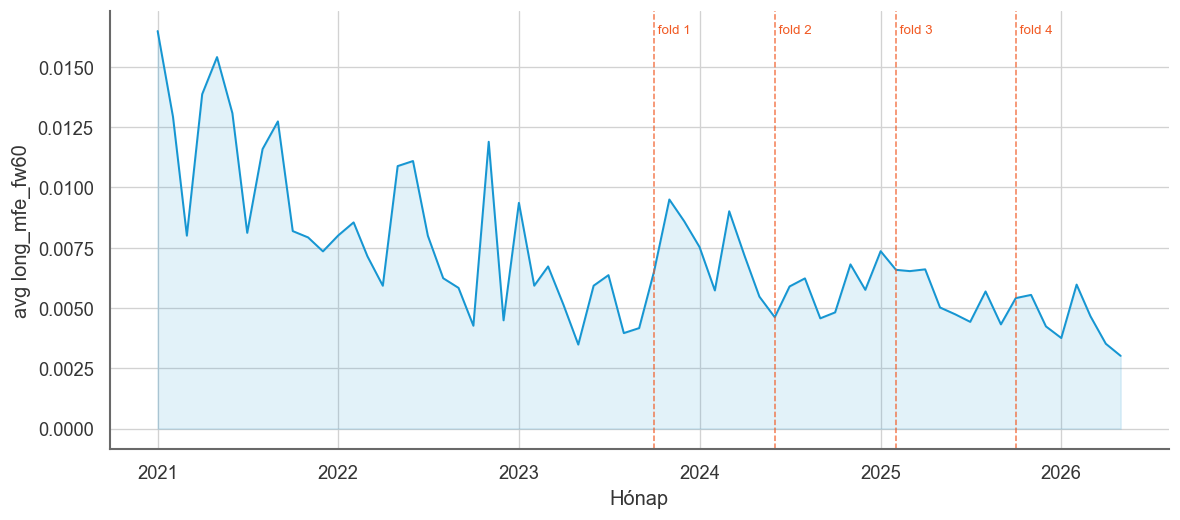

In [5]:
#| label: fig-monthly-avg-target
#| fig-cap: "Havi átlagos long_mfe_fw60 — a fold határokat függőleges vonalak jelölik"
#| fig-alt: "Vonaldiagram: havi átlagos long_mfe_fw60 2021-től 2026-ig, csökkenő trenddel."

con = duckdb.connect(LAB_DB, read_only=True)
monthly = con.execute(f"""
    SELECT
        DATE_TRUNC('month', open_time) AS month,
        AVG(long_mfe_fw60)             AS avg_target,
        MIN(fold_id)                   AS fold_min
    FROM {SAMPLE_TABLE}
    GROUP BY 1
    ORDER BY 1
""").fetchdf()
_fold_starts = con.execute(f"""
    SELECT fold_id, MIN(open_time) AS fold_start
    FROM {SAMPLE_TABLE}
    WHERE fold_id > 0
    GROUP BY fold_id
    ORDER BY fold_id
""").fetchdf()
con.close()

monthly["month"] = pd.to_datetime(monthly["month"])
_fold_starts["fold_start"] = pd.to_datetime(_fold_starts["fold_start"])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly["month"], monthly["avg_target"], color=CQ_COLORS["blue"], linewidth=1.2)
ax.fill_between(monthly["month"], monthly["avg_target"], alpha=0.12, color=CQ_COLORS["blue"])

for _, row in _fold_starts.iterrows():
    ax.axvline(
        x=row["fold_start"], color=CQ_COLORS["orange"],
        linestyle="--", linewidth=0.9, alpha=0.8,
    )
    ax.text(
        row["fold_start"], ax.get_ylim()[1] * 0.97,
        f" fold {int(row['fold_id'])}",
        color=CQ_COLORS["orange"], fontsize=8, va="top",
    )

ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.4f"))
ax.set_xlabel("Hónap")
ax.set_ylabel("avg long_mfe_fw60")
plt.tight_layout()
plt.show()

## Értelmezés

In [6]:
#| label: tbl-interpretation-summary
#| tbl-cap: "Értelmezési összefoglaló — fold-szintű target metrikák"

con = duckdb.connect(LAB_DB, read_only=True)
_interp = con.execute(f"""
    SELECT
        fold_id,
        COUNT(*)             AS count,
        AVG(long_mfe_fw60)   AS avg_target,
        STDDEV(long_mfe_fw60) AS std_target,
        MIN(long_mfe_fw60)   AS min_target,
        MAX(long_mfe_fw60)   AS max_target
    FROM {SAMPLE_TABLE}
    GROUP BY fold_id
    ORDER BY fold_id
""").fetchdf()
con.close()

_interp["segment"] = _interp["fold_id"].map(lambda x: "train-only" if x == 0 else f"valid {x}")
_valid = _interp[_interp["fold_id"] > 0]
_target_drop_pct = (
    (_valid["avg_target"].iloc[-1] - _valid["avg_target"].iloc[0])
    / _valid["avg_target"].iloc[0] * 100
)
_train_avg = _interp.loc[_interp["fold_id"] == 0, "avg_target"].iloc[0]
_valid_avg = _valid["avg_target"].mean()
_train_valid_gap = (_valid_avg - _train_avg) / _train_avg * 100

display_analysis_table(_interp[["fold_id", "segment", "count", "avg_target", "std_target", "min_target", "max_target"]])

display(Markdown(f"""
**Főbb megállapítások:**

- **Teljes lefedettség:** {_interp['count'].sum():,} sor, 2021-01 – 2026-05 (kb. 65 hónap).
- **Train-only pool (fold 0):** {int(_interp.loc[_interp['fold_id']==0,'count'].iloc[0]):,} sor —
  az összes sor ~{_interp.loc[_interp['fold_id']==0,'count'].iloc[0]/_interp['count'].sum()*100:.0f}%-a.
  Ez lefedi az anchor előtti és a 4 fold train-ablakainak uniója.
- **Valid foldok mérete:** {int(_valid['count'].mean()):,} sor/fold (szórás: {int(_valid['count'].std()):.0f}) —
  konzisztens, az 5 760 elméleti értékhez közel.
- **Csökkenő target trend:** fold 1 avg_target = {_valid['avg_target'].iloc[0]:.4f},
  fold 4 avg_target = {_valid['avg_target'].iloc[-1]:.4f}
  (változás: {_target_drop_pct:.1f}%). A SOL long-oldali MFE szisztematikusan csökkent
  2023 Q4-től 2026-ig.
- **Train vs. valid gap:** a train-only átlag ({_train_avg:.4f}) {abs(_train_valid_gap):.1f}%-kal
  {'magasabb' if _train_valid_gap > 0 else 'alacsonyabb'} a valid foldok átlagánál ({_valid_avg:.4f}).
  Ez részben az early bull market évek (2021–2022) train poolba való beolvadásának következménye.

**Döntési szempontok:**

A sampling szerkezet technikailag helyes: egyenletes fold-méretek, tiszta időrendi határ
train és valid között, nincs adatszivárgás. A target degradáció (fold 1 → 4) nem
mintavételezési hiba — a piac tényleges viselkedésbeli változása. A modell search-objective
(Top10 Lift fold-stability penaltyvel) éppen ezért használ multi-fold átlagolást, hogy
ne fittelje túl a korai foldok magasabb target-szintjét.
"""))

fold_id,segment,count,avg_target,std_target,min_target,max_target
0,train-only,24072,0.008,0.012,-0.013,0.278
1,valid 1,5856,0.007,0.008,-0.008,0.086
2,valid 2,5880,0.006,0.007,-0.007,0.097
3,valid 3,5808,0.005,0.007,-0.008,0.141
4,valid 4,5832,0.004,0.005,-0.006,0.065



**Főbb megállapítások:**

- **Teljes lefedettség:** 47,448 sor, 2021-01 – 2026-05 (kb. 65 hónap).
- **Train-only pool (fold 0):** 24,072 sor —
  az összes sor ~51%-a.
  Ez lefedi az anchor előtti és a 4 fold train-ablakainak uniója.
- **Valid foldok mérete:** 5,844 sor/fold (szórás: 30) —
  konzisztens, az 5 760 elméleti értékhez közel.
- **Csökkenő target trend:** fold 1 avg_target = 0.0074,
  fold 4 avg_target = 0.0045
  (változás: -39.6%). A SOL long-oldali MFE szisztematikusan csökkent
  2023 Q4-től 2026-ig.
- **Train vs. valid gap:** a train-only átlag (0.0084) 31.4%-kal
  alacsonyabb a valid foldok átlagánál (0.0058).
  Ez részben az early bull market évek (2021–2022) train poolba való beolvadásának következménye.

**Döntési szempontok:**

A sampling szerkezet technikailag helyes: egyenletes fold-méretek, tiszta időrendi határ
train és valid között, nincs adatszivárgás. A target degradáció (fold 1 → 4) nem
mintavételezési hiba — a piac tényleges viselkedésbeli változása. A modell search-objective
(Top10 Lift fold-stability penaltyvel) éppen ezért használ multi-fold átlagolást, hogy
ne fittelje túl a korai foldok magasabb target-szintjét.
